In [ ]:
#!pip install evaluate rouge_score

## Bibliotecas

In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
import evaluate
from collections import Counter

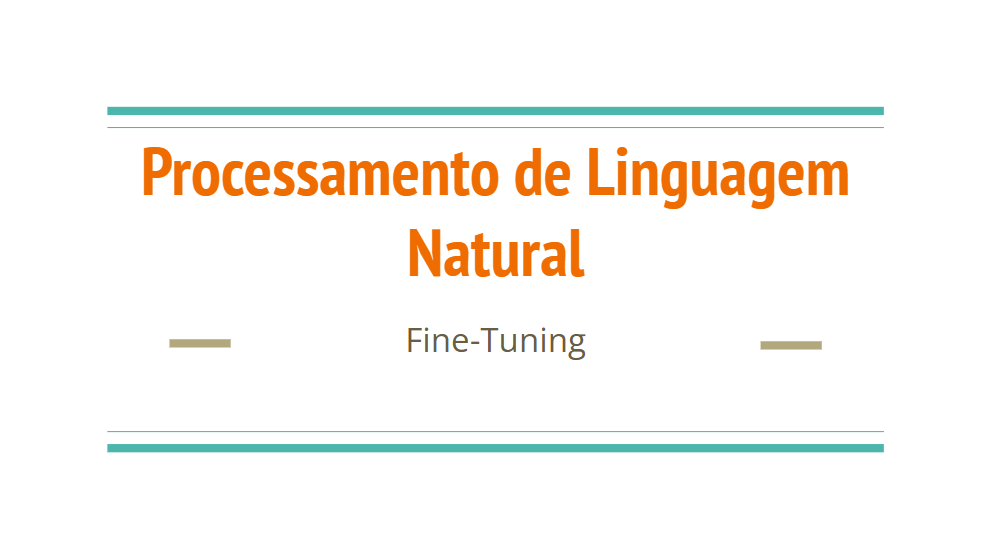

## Introdução


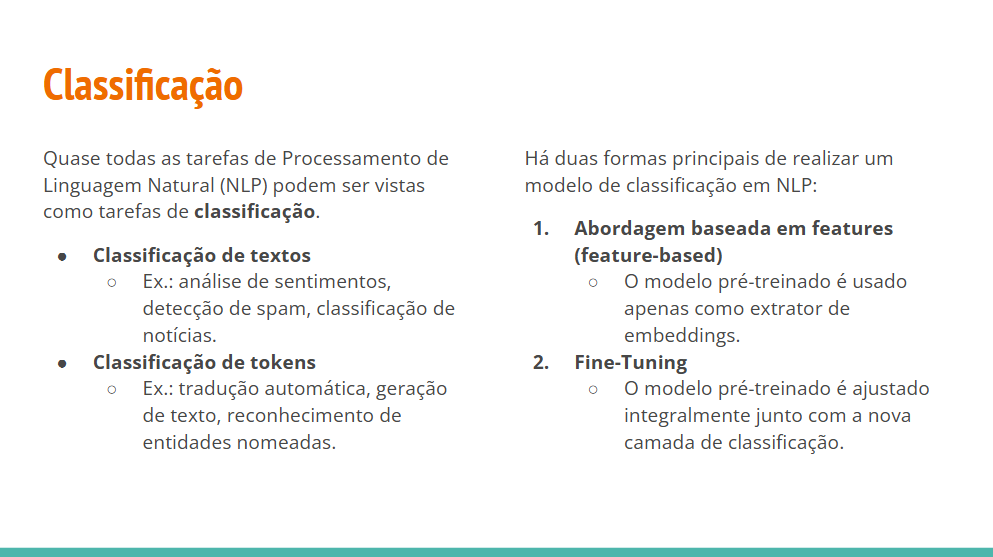

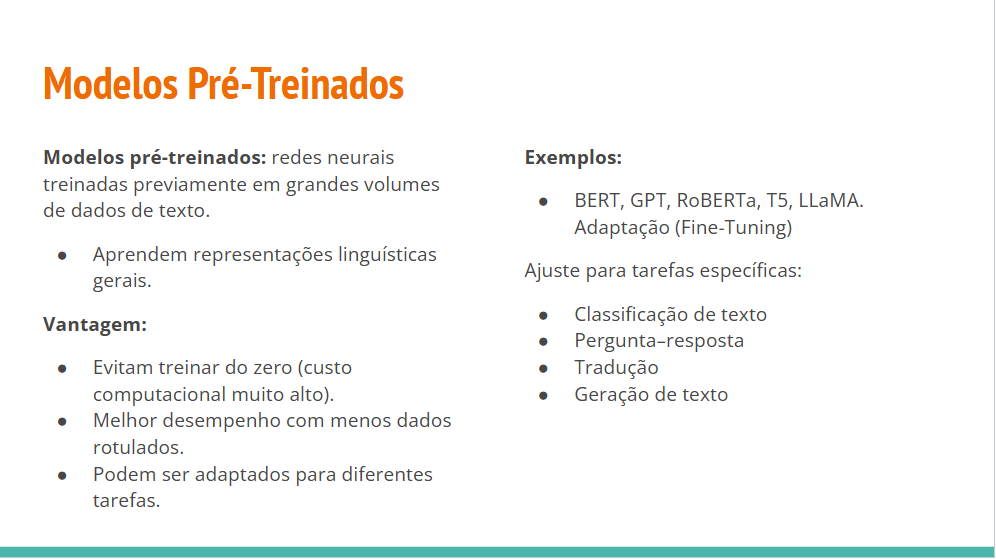

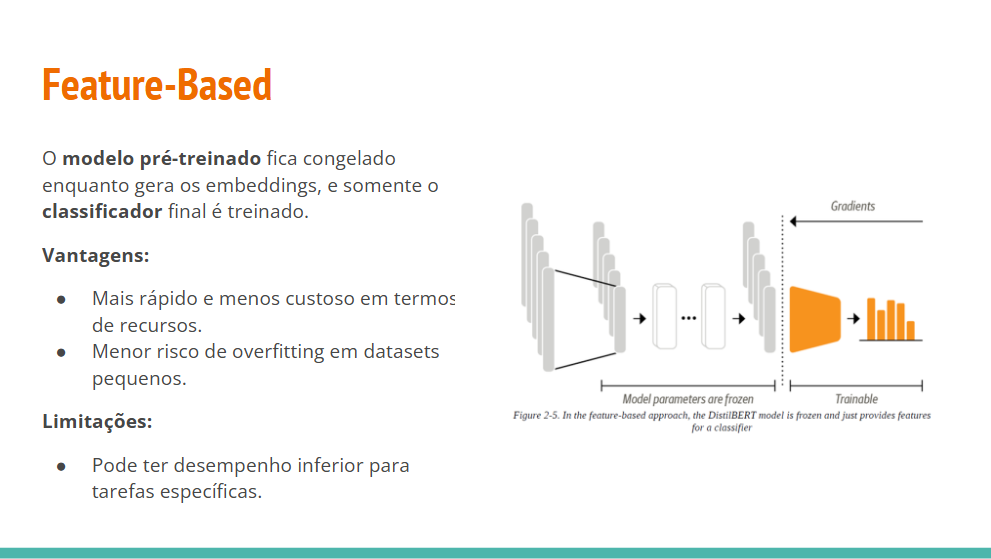

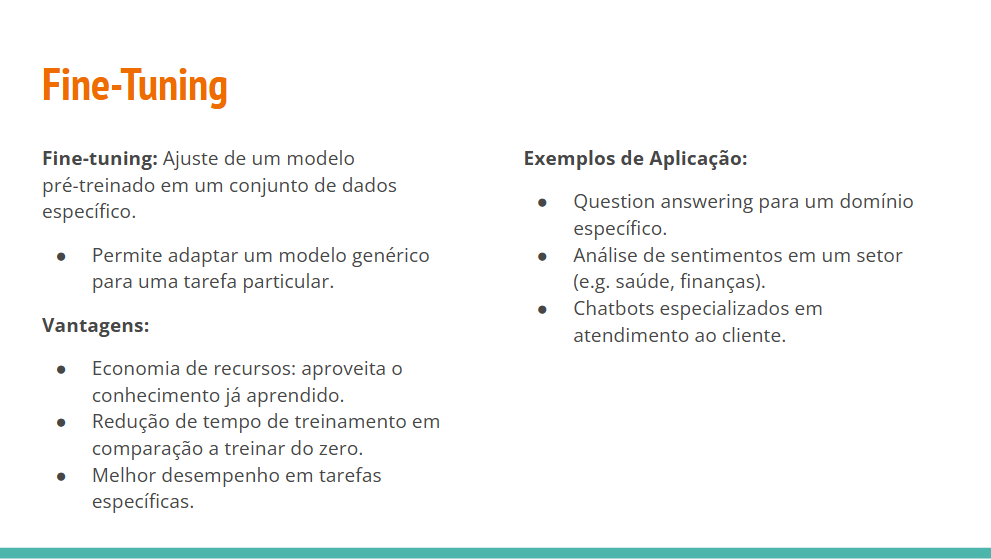

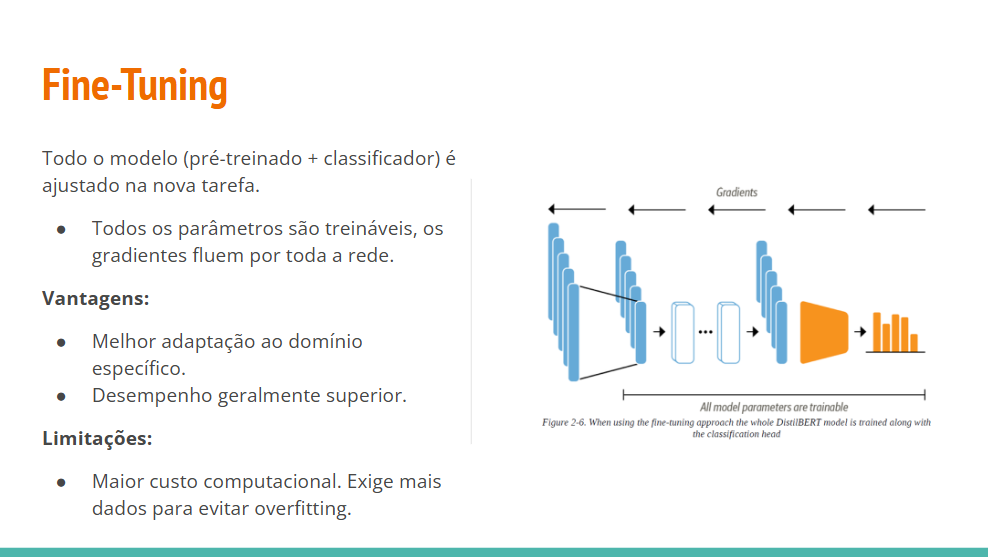

### Exemplo

Vamos mostrar uma aplicação de fine-tuning no dataset IMDb, que contém resenhas de filmes classificadas como positivas ou negativas. A ideia é pegar um modelo de linguagem já pré-treinado e ajustá-lo especificamente para a tarefa de análise de sentimentos, aproveitando o poder do modelo sem precisar treiná-lo do zero.

**Link:** https://huggingface.co/datasets/stanfordnlp/imdb

In [ ]:
# Carregar dataset
dataset = load_dataset("imdb")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
# Divisão por label
train_labels = dataset["train"]["label"]

print(Counter(train_labels))

Counter({0: 12500, 1: 12500})


In [ ]:
# Escolher modelo pré-treinado
checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
# Tokenizar
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
# Dividir em treino e teste
small_train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(2000))
small_eval_dataset = tokenized_datasets["test"].shuffle(seed=42).select(range(1000))

In [ ]:
# Modelo para classificação binária
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Métricas: Accuracy + F1
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy.compute(predictions=preds, references=labels)
    f1_macro = f1.compute(predictions=preds, references=labels, average="macro")

    return {
        "accuracy": acc["accuracy"],
        "f1_macro": f1_macro["f1"]
    }

In [ ]:
# Configuração do treinamento
training_args = TrainingArguments(
    report_to="none", # Para ignorar a API do wandb
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01
)

# Trainer API
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train_dataset,
    eval_dataset=small_eval_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

# Treinamento
trainer.train()

/tmp/ipython-input-1890611543.py:13: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,0.362223,0.893000,0.892997
2,No log,0.380233,0.895000,0.894999


TrainOutput(global_step=250, training_loss=0.15641441345214843, metrics={'train_runtime': 230.8211, 'train_samples_per_second': 17.329, 'train_steps_per_second': 1.083, 'total_flos': 529869594624000.0, 'train_loss': 0.15641441345214843, 'epoch': 2.0})

In [ ]:
# Avaliação
eval_results = trainer.evaluate()

print(eval_results)

{'eval_loss': 0.3802325427532196, 'eval_accuracy': 0.895, 'eval_f1_macro': 0.8949990549914949, 'eval_runtime': 17.8363, 'eval_samples_per_second': 56.065, 'eval_steps_per_second': 3.532, 'epoch': 2.0}


**Exercício:** Utilize outros modelos transformer para classificação e compare os resultados. Alguns exemplos:

* bert-base-uncased

* roberta-base

* albert-base-v2

Modifique também os argumentos de treinamento para tentar obter resultados melhores.

## Aplicações

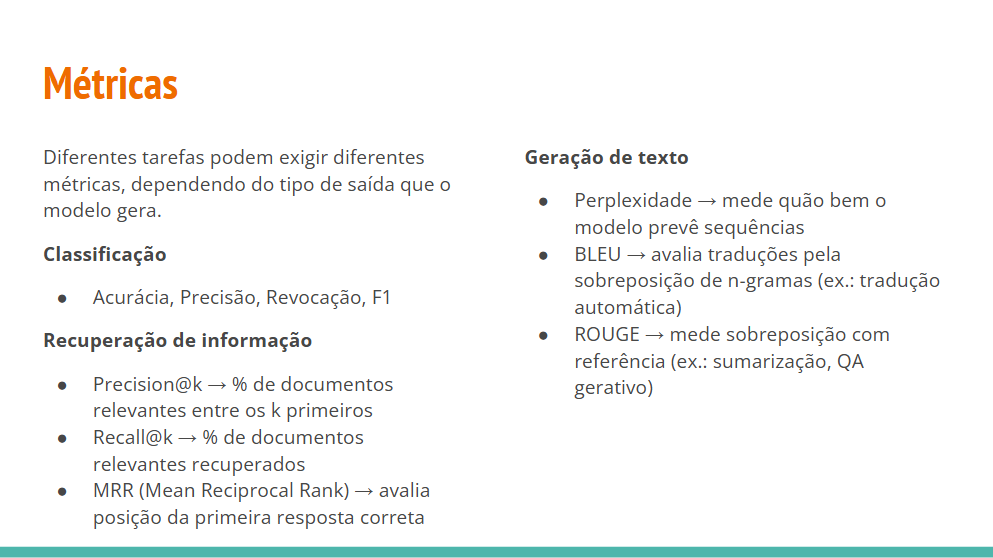

### Sumarização

O objetivo desta tarefa é realizar fine-tuning de um modelo Transformer em uma tarefa de **geração de resumos**. Vamos usar o dataset CNN/DailyMail (3.0.0), que contém artigos de notícias acompanhados de resumos curtos elaborados por humanos.

* **Dataset:** cnn_dailymail, versão "3.0.0"

* **Modelo:** t5-small

* **Arquitetura:** AutoModelForSeq2SeqLM

Estrutura de dados:
* **Entrada:** um artigo de notícia.
* **Saída:** um resumo curto.

### Tradução


O objetivo desta tarefa é realizar fine-tuning de um modelo Transformer em uma tarefa de **tradução** de **inglês** para **espanhol**. Vamos usar o dataset Opus Books (en-es), que contém pares de frases alinhadas entre as duas línguas.

* **Dataset:** opus_books, configuração "en-es"

* **Modelo:** t5-small

* **Arquitetura:** AutoModelForSeq2SeqLM

Estrutura de dados:

* **Entrada:** uma frase em inglês, no formato: `translate English to Spanish: <frase em inglês>`

* **Saída:** a tradução correspondente em espanhol.